### Are internet searches still informative?

In this example, I highlight three challenges on the use of internet searches (Google Trends) for economic forecasting, namely:

* Data quality;
* Issue on scale; and
* Representativeness.

I will conclude with key best practices and caution in the use of GT for research.

In [ ]:
%%capture
!pip install pytrends


#https://www.lovethephilippines.travel/tourism/demand-statistics

In [108]:
# load the environments for visualization and analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import tqdm
from pytrends.request import TrendReq # for Google Trends data



### Google Trend (GT) variables
GT variables can be categorized as keywords, topics, and categories.


In [114]:
#sample series
GEO_LOC = 'PH'
Trending_topics = TrendReq(hl='en-US', tz=360)

list_kwlist = [["typhoon"],
               ["election"],
               ["covid"]]

for i, kw_list in enumerate(list_kwlist):
    Trending_topics.build_payload(kw_list,
                                timeframe='all', #all data (monthly)
                                geo=GEO_LOC)
    df_out = Trending_topics.interest_over_time()
    df_out.to_csv(f'./1_data/{kw_list[0]}.csv')
    time.sleep(10)

/Users/mlgcastanares/opt/anaconda3/envs/BankSentiment/lib/python3.11/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/Users/mlgcastanares/opt/anaconda3/envs/BankSentiment/lib/python3.11/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/Users/mlgcastanares/opt/anaconda3/envs/BankSentiment/lib/python3.11/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will cha

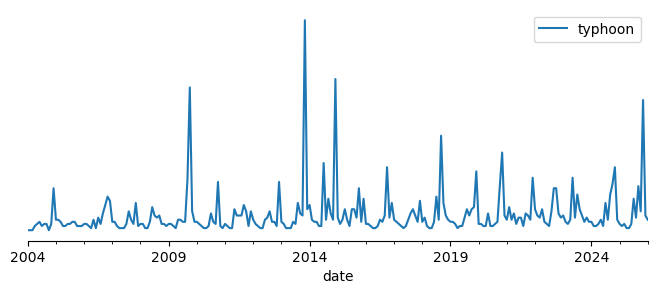

In [126]:
df_out = pd.read_csv('./1_data/typhoon.csv', index_col=0, parse_dates=True)
df_out.plot(figsize=(8,3))

# format
# remove border
for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)


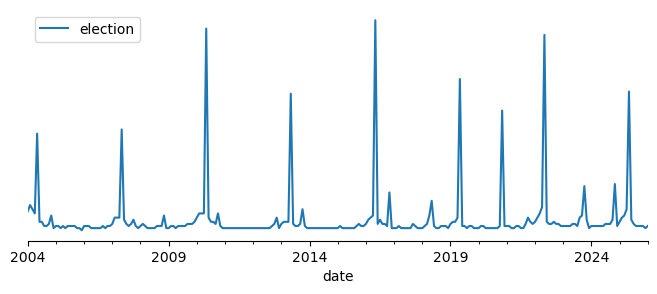

In [127]:
df_out = pd.read_csv('./1_data/election.csv', index_col=0, parse_dates=True)
df_out.plot(figsize=(8,3))

# format
# remove border
for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)


(588.0, 672.0)

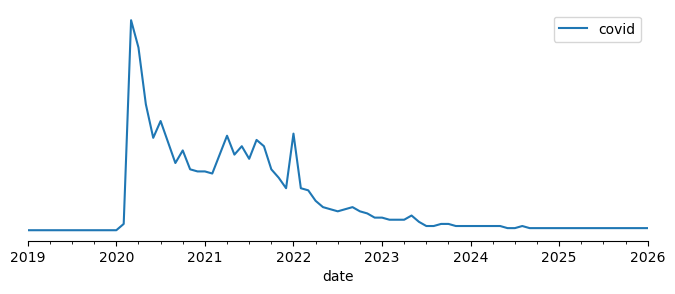

In [163]:
df_out = pd.read_csv('./1_data/covid.csv', index_col=0, parse_dates=True)
fig, ax = plt.subplots(1,1,figsize=(8,3))
df_out.plot(ax=ax)

# format
# remove border
for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)
ax.set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2026-01-01'))

In [131]:
Trending_topics = TrendReq(hl='en-US', tz=360)
Trending_topics.build_payload(kw_list=[""],
                            cat = 29, # real estate
                            timeframe='all', #all data (monthly)
                            geo=GEO_LOC)
df_out = Trending_topics.interest_over_time()
df_out.to_csv(f'./1_data/real_estate.csv')
time.sleep(10)

/Users/mlgcastanares/opt/anaconda3/envs/BankSentiment/lib/python3.11/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [145]:
df_rrepi = pd.read_csv('./1_data/rrepi.csv', index_col=0, parse_dates=True).dropna()
df_rrepi

,Unnamed: 1,isPartial
date,,
2019-01-01,96.3,False
2019-04-01,99.9,False
2019-07-01,100.4,False
2019-10-01,103.3,False
2020-01-01,103.7,False
2020-04-01,108.6,False
2020-07-01,106.8,False
2020-10-01,107.4,False
2021-01-01,108.0,False


,Real Estate,isPartial,rrepi
date,,,
2023-08-01,88,False,NaN
2023-09-01,80,False,NaN
2023-10-01,97,False,133.1
2023-11-01,78,False,NaN
2023-12-01,77,False,NaN
2024-01-01,92,False,139.4
2024-02-01,87,False,NaN
2024-03-01,83,False,NaN
2024-04-01,83,False,145.3


(588.0, 672.0)

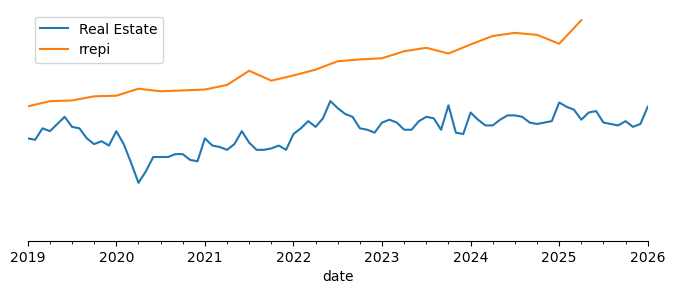

In [158]:
df_out = pd.read_csv('./1_data/real_estate.csv', index_col=0, parse_dates=True)
df_rrepi = pd.read_csv('./1_data/rrepi.csv', index_col=0, parse_dates=True).dropna()

df_out.columns = ['Real Estate', 'isPartial']
df_rrepi.columns = ['rrepi','is_Partial']
df_out['rrepi'] = df_rrepi['rrepi']

display(df_out.tail(30))

fig, ax = plt.subplots(1,1,figsize=(8,3))
df_out['Real Estate'].plot(ax=ax, legend=True)
df_out['rrepi'].interpolate(limit_direction='backward').plot(ax=ax, legend=True)

# format
# remove border
for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)
ax.set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2026-01-01'))

In [159]:
df_out.dropna(how='any',axis=0).corr()

,Real Estate,isPartial,rrepi
Real Estate,1.000000,NaN,0.627543
isPartial,NaN,NaN,NaN
rrepi,0.627543,NaN,1.000000


#### Data Quality

In [ ]:
# get the current time
time.time()
#format time to readable


'172320'

In [ ]:
start = time.time()

#USER INPUTS
kw_list=[""]
CAT_IN = 67 #Travel see https://github.com/pat310/google-trends-api/wiki/Google-Trends-Categories

df_out = pd.DataFrame([])
for i in tqdm.tqdm(range(30)):
    tag = time.ctime().split(' ')[3].replace(':','')
    kw_str = ''.join(kw_list)
    Trending_topics.build_payload(kw_list,
                                  cat=CAT_IN,
                                  timeframe='all', #all data (monthly)
                                  geo=GEO_LOC)
    df_out = Trending_topics.interest_over_time()
    df_out.to_csv(f'./1_data/kw{kw_str}_cat{CAT_IN}_{tag}.csv')
    time.sleep(60*2) #pause to avoid rate limiting

print(f"Total time taken: {time.time() - start} seconds")

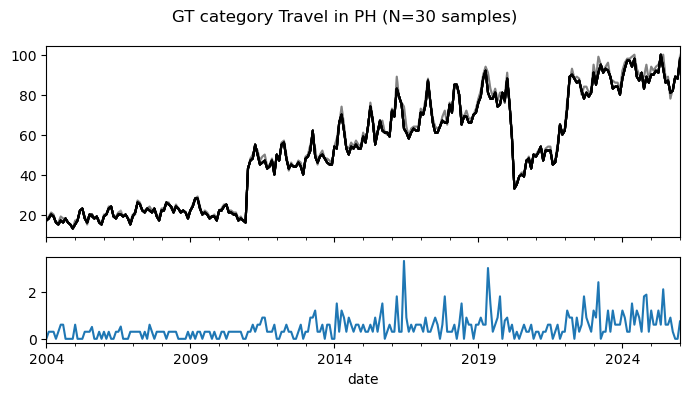

In [79]:
#plot graphs to show difference in sampling

import os
from matplotlib.gridspec import GridSpec

files = [x for x in os.listdir('./1_data/') if x.endswith('.csv')]
files.sort()

df_list = pd.DataFrame([])
for file in files:
    tag = file.split('_')[-1].replace('.csv','')    
    df_temp = pd.read_csv(f'./1_data/{file}',
                          index_col=0,
                          parse_dates=True).iloc[:,0]
    df_list[f'{tag}'] = df_temp


fig = plt.figure(figsize=(7,4))
gs = GridSpec(3, 1, figure=fig)
ax1 = fig.add_subplot(gs[0:2])
ax2 = fig.add_subplot(gs[2],sharex=ax1)

df_list.plot(legend=False,
             alpha = 0.2,
             color='k',
             ax=ax1)
df_agg = df_list.agg(['mean','std'], axis=1)
df_agg.loc[:,'std'].plot(ax=ax2)

fig.suptitle('GT category Travel in PH (N=30 samples)')

#share x-axis
fig.tight_layout()

<Axes: xlabel='date'>

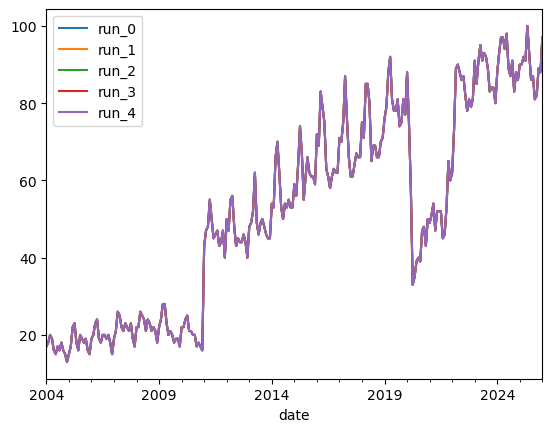

In [37]:
df_out.plot()

### Issue on scale

In [ ]:
#show end-point as partial

### Representativeness

In [ ]:
#simple correlation

#sample time-series travel, unemployment rate, GDP, 

#direction and sign
#fitting with covid dip

### Best practices

In [ ]:
# multiple draws
# constant reassessment/retraining with models
# broader